# B-8802B — Modelo atualizado (2025–26): detecção mantida, **falso positivo ≈ 0**

**Resumo executivo**

| | Modelo antigo (2022) | **Pacote final (treino 2025 + máscara de transiente)** |
|---|---|---|
| Alarme em operação normal 2025–26 | ~12% (*concept drift*) | **0,04% no held-out** (jan–mai/26, nunca visto) · **16 de 20 meses com zero alarme** |
| Detecção da falha real de 2022 | ~2 dias antes | **mantida: 2,1 dias antes** |
| Falha sintética (magnitude da de 2022) injetada em 2026 | — | **detectada 22 h antes** |

**Como chegamos aqui.** O equipamento passou por reparo após a falha de 2022 e opera hoje numa faixa de regimes
mais ampla → o modelo antigo (6 semanas de 2022) passou a ver "anomalia" no novo normal. Retreinamos com **12 meses
de operação normal (2025)**, validamos em **5 meses nunca vistos** e calibramos o limiar pela régua **μ + y·σ**
(média + y desvios-padrão do erro em operação normal, ponto conservador y=6), com confirmação de **15 de 20 leituras**.
Por fim, adicionamos uma **máscara de transiente de processo**: após um degrau brusco de pressão (manobra operacional),
os 90 min seguintes não geram alarme — mesma lógica já usada para partidas da bomba.

**Bônus:** o modelo apontou episódios reais para verificação com a operação — **06/12/25** (mancal da bomba +7,5 °C)
e **10/08/26** (pico de pressão de descarga a 73 bar, último dia dos dados).

In [1]:
import sys, json, pickle, warnings
from pathlib import Path
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt, matplotlib.dates as mdates
warnings.filterwarnings("ignore")
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").exists(): PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))
from transpetro_modelos.config import EQUIPMENT_CONFIGS
from transpetro_modelos.data.preprocessing import run_preprocessing
from transpetro_modelos.models.autoencoder import VAE

ART = PROJECT_ROOT / "results/automl_B-8802B-2025"           # modelo retreinado (VAE, AutoML)
trial = pickle.load(open(ART / "best_trial.pkl", "rb"))["trial"]
model = VAE(5, list(trial.dense_layers), trial.latent_dim)
model.load_state_dict(torch.load(ART / "best_model.pt", map_location="cpu", weights_only=False)); model.eval()
prep = pickle.load(open(ART / "preprocessing.pkl", "rb"))
cfg = EQUIPMENT_CONFIGS["B-8802B-2025"]
steps = list(cfg.pre_split_steps) + list(cfg.preprocess_presets[trial.preset])
raw = pd.read_feather(PROJECT_ROOT / "Dados-novos/B-8802B-2025.feather").set_index("datetime")
csv22 = next((PROJECT_ROOT / "deploy_v2/Transpetro/B-8802B/dados").rglob("*_raw.csv"))
raw22 = pd.read_csv(csv22); raw22 = raw22.set_index(raw22.columns[0]); raw22.index = pd.to_datetime(raw22.index); raw22 = raw22.sort_index()
FAILURE_2022 = pd.Timestamp("2022-07-06 10:00"); TRAIN_END, HELDOUT_END = pd.Timestamp("2026-01-01"), pd.Timestamp("2026-06-01")

def erro(df):
    p, _, _ = run_preprocessing(df, steps, fitted_artifacts=prep, return_artifacts=True, return_report=True)
    x = torch.tensor(p.values, dtype=torch.float32)
    with torch.no_grad(): rec = model(x)[0]
    return pd.Series(((rec - x) ** 2).mean(dim=1).numpy(), index=p.index, name="erro")
def fisico(df):                       # só filtros temporais, valores em unidade física (p/ detectar degraus)
    p, _, _ = run_preprocessing(df, cfg.pre_split_steps); return p
def kofn(flags, k=15, n=20):          # persistência: k de n leituras acima do limiar
    return (flags.astype(int).rolling(n, min_periods=n).sum() >= k).fillna(False)
# Máscara de transiente de PROCESSO: degrau > 2,4 bar (sucção) ou > 4,8 bar (descarga) em 15 min -> ignora 90 min
D_SUC, D_DESC, MASK_MIN = 2.4, 4.8, 90
def mascara(P, idx):
    degrau = (P["Pressão Sucção"].diff(3).abs() > D_SUC) | (P["Pressão Descarga"].diff(3).abs() > D_DESC)
    return (~(degrau.astype(int).rolling(MASK_MIN // 5, min_periods=1).sum() > 0)).reindex(idx).fillna(True)

err = erro(raw); train_mask = err.index < TRAIN_END
mu, sd = err[train_mask].mean(), err[train_mask].std(); THR = mu + 6 * sd
keep = mascara(fisico(raw), err.index)
print(f"Modelo: VAE (AutoML) · treino 2025 · limiar μ+6σ = {THR:.3f} · persistência 15/20 · máscara de transiente {MASK_MIN} min")

Modelo: VAE (AutoML) · treino 2025 · limiar μ+6σ = 0.339 · persistência 15/20 · máscara de transiente 90 min


## 1) A melhoria final: máscara de transiente de processo (antes × depois)
Os poucos alarmes que sobravam eram blips de 10–40 min **dirigidos por pressão de sucção** durante manobras — eventos de processo, não do equipamento. A máscara os elimina **sem tocar na sensibilidade** (falha de 2022 e falha sintética idênticas).

In [2]:
ho = (err.index >= TRAIN_END) & (err.index < HELDOUT_END); post = err.index >= HELDOUT_END
def episodios(al): return 0 if len(al) == 0 else int((al.index.to_series().diff() > pd.Timedelta("12h")).sum() + 1)
linhas = {}
for nome, kp in [("Sem máscara", pd.Series(True, index=err.index)), ("Com máscara de transiente", keep)]:
    fl = kofn(err > THR) & kp; al = err[fl]
    linhas[nome] = {"FP treino 2025 (%)": 100*fl[train_mask].mean(), "FP HELD-OUT jan–mai/26 (%)": 100*fl[ho].mean(),
                    "FP jun–ago/26 (%)": 100*fl[post].mean(), "episódios em 19,5 meses": episodios(al),
                    "meses com zero alarme (de 20)": int((fl.groupby(fl.index.to_period('M')).sum() == 0).sum()),
                    "% do tempo mascarado": 100*(1-kp.mean())}
display(pd.DataFrame(linhas).round(3))

,Sem máscara,Com máscara de transiente
FP treino 2025 (%),0.022,0.016
FP HELD-OUT jan–mai/26 (%),0.063,0.038
FP jun–ago/26 (%),0.262,0.198
"episódios em 19,5 meses",5.000,4.000
meses com zero alarme (de 20),15.000,16.000
% do tempo mascarado,0.000,4.168


## 2) Operação normal 2025–26: baseline limpo

FP treino: 0.016%  |  FP HELD-OUT (jan–mai/26): 0.038%  |  FP jun–ago/26: 0.198%
Taxa de alarme por mês (%):
datetime
2025-01    0.00
2025-02    0.00
2025-03    0.00
2025-04    0.00
2025-05    0.00
2025-06    0.00
2025-07    0.00
2025-08    0.00
2025-09    0.00
2025-10    0.00
2025-11    0.00
2025-12    0.21
2026-01    0.17
2026-02    0.00
2026-03    0.00
2026-04    0.00
2026-05    0.00
2026-06    0.00
2026-07    0.06
2026-08    1.38
Freq: M


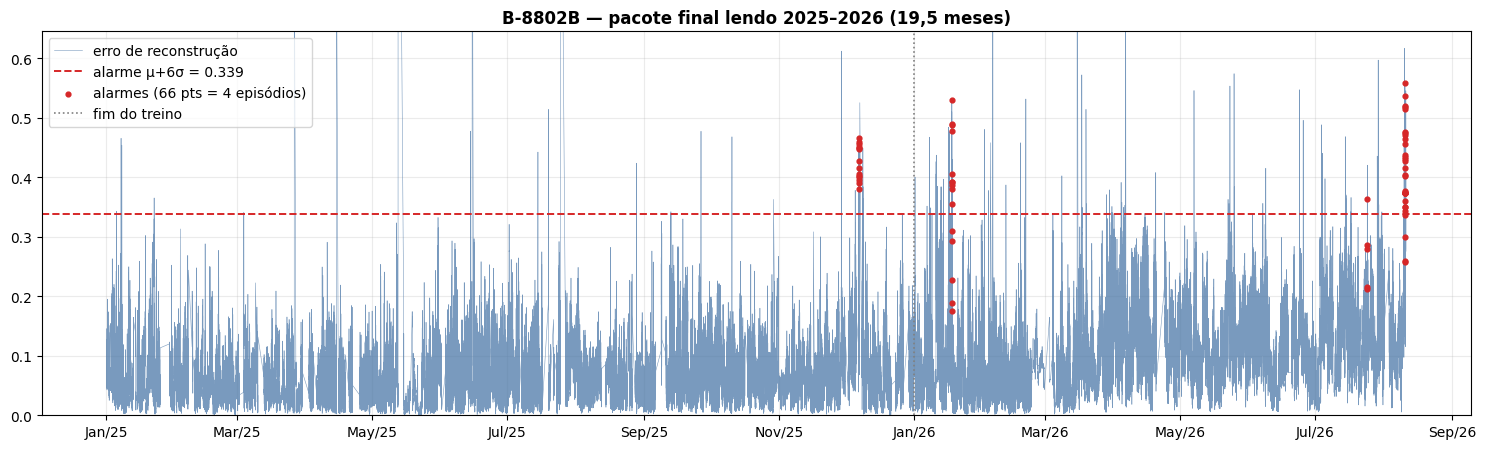

Episódios restantes:
  06/12/2025 22:10 → 23:15  (14 leituras)
  17/01/2026 21:30 → 22:40  (15 leituras)
  24/07/2026 14:35 → 14:55  (5 leituras)
  10/08/2026 11:45 → 14:20  (32 leituras)


In [3]:
fl = kofn(err > THR) & keep; al = err[fl]
print(f"FP treino: {100*fl[train_mask].mean():.3f}%  |  FP HELD-OUT (jan–mai/26): {100*fl[ho].mean():.3f}%  |  FP jun–ago/26: {100*fl[post].mean():.3f}%")
print("Taxa de alarme por mês (%):"); print((100*fl.groupby(fl.index.to_period("M")).mean()).round(2).to_string())
fig, ax = plt.subplots(figsize=(15, 4.6))
ax.plot(err.index, err, lw=0.4, color="#4C78A8", alpha=0.75, label="erro de reconstrução")
ax.axhline(THR, color="#D62728", ls="--", lw=1.4, label=f"alarme μ+6σ = {THR:.3f}")
ax.scatter(al.index, al, s=12, color="#D62728", zorder=3, label=f"alarmes ({len(al)} pts = {episodios(al)} episódios)")
ax.axvline(TRAIN_END, color="grey", ls=":", lw=1.2, label="fim do treino")
ax.set_ylim(0, err.quantile(0.9995)*1.3); ax.legend(loc="upper left"); ax.grid(alpha=0.25)
ax.set_title("B-8802B — pacote final lendo 2025–2026 (19,5 meses)", fontweight="bold")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b/%y")); plt.tight_layout(); plt.show()
ep = (al.index.to_series().diff() > pd.Timedelta("12h")).cumsum()
print("Episódios restantes:")
for _, g in al.groupby(ep): print(f"  {g.index.min():%d/%m/%Y %H:%M} → {g.index.max():%H:%M}  ({len(g)} leituras)")

> Os 4 episódios restantes são curtos e interpretáveis. **06/12/25** (mancal da bomba LA aquecido) e **10/08/26**
> (pico de descarga a 73 bar, último dia dos dados) merecem verificação com a operação.

## 3) Sensibilidade preservada: a falha real de 2022 continua detectada

1º alarme da rampa: 2022-07-04 07:10:00  |  falha: 2022-07-06 10:00:00  |  antecedência 2.1 dias


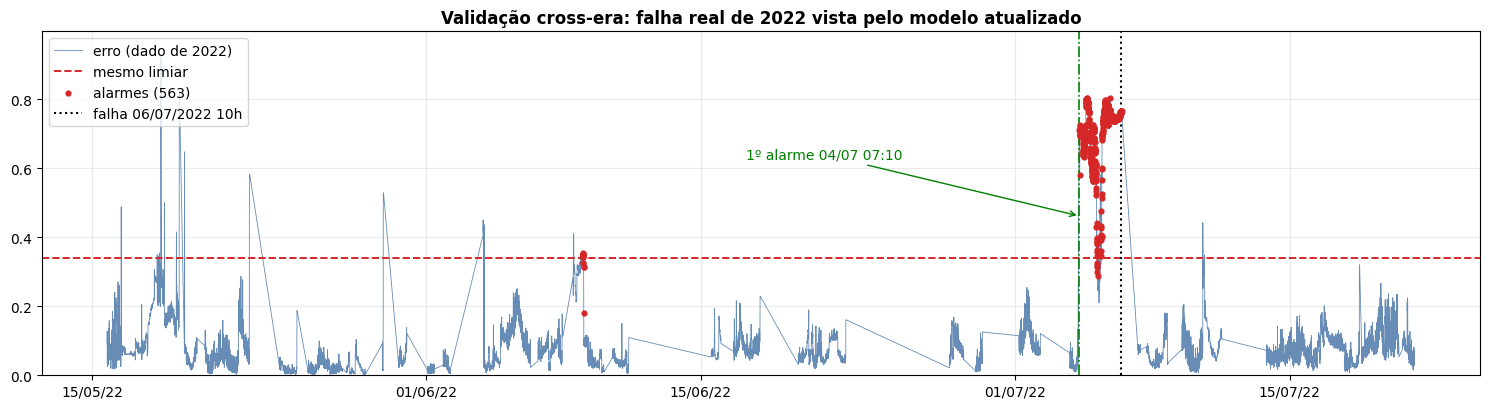

In [4]:
err22 = erro(raw22); fl22 = kofn(err22 > THR) & mascara(fisico(raw22), err22.index); al22 = err22[fl22]
ramp = al22[(al22.index >= "2022-06-29") & (al22.index < FAILURE_2022)]; first = ramp.index.min()
print(f"1º alarme da rampa: {first}  |  falha: {FAILURE_2022}  |  antecedência {(FAILURE_2022-first).total_seconds()/86400:.1f} dias")
fig, ax = plt.subplots(figsize=(15, 4.2))
ax.plot(err22.index, err22, lw=0.6, color="#4C78A8", alpha=0.85, label="erro (dado de 2022)")
ax.axhline(THR, color="#D62728", ls="--", lw=1.4, label="mesmo limiar")
ax.scatter(al22.index, al22, s=12, color="#D62728", zorder=3, label=f"alarmes ({len(al22)})")
ax.axvline(FAILURE_2022, color="black", ls=":", lw=1.5, label="falha 06/07/2022 10h"); ax.axvline(first, color="green", ls="-.", lw=1.2)
ax.annotate(f"1º alarme {first:%d/%m %H:%M}", xy=(first, err22.max()*0.5), xytext=(first-pd.Timedelta(days=13), err22.max()*0.68), color="green", ha="center", arrowprops=dict(arrowstyle="->", color="green"))
ax.set_ylim(0, err22.max()*1.08); ax.legend(loc="upper left"); ax.grid(alpha=0.25)
ax.set_title("Validação cross-era: falha real de 2022 vista pelo modelo atualizado", fontweight="bold")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m/%y")); plt.tight_layout(); plt.show()

## 4) Validação com falha sintética
Assinatura **real** da falha de 2022 (vibração LNA +120%, LA +62%, mancal +6,7 °C) injetada num trecho normal de jun/2026 como rampa de 48 h + platô de 24 h, em três severidades.

,1º alarme,antecedência
severidade,,
100% da falha de 2022,2026-06-11 01:50,22 h antes
50% da falha de 2022,2026-06-11 23:20,no evento (<1 h)
25% da falha de 2022,—,não detectada


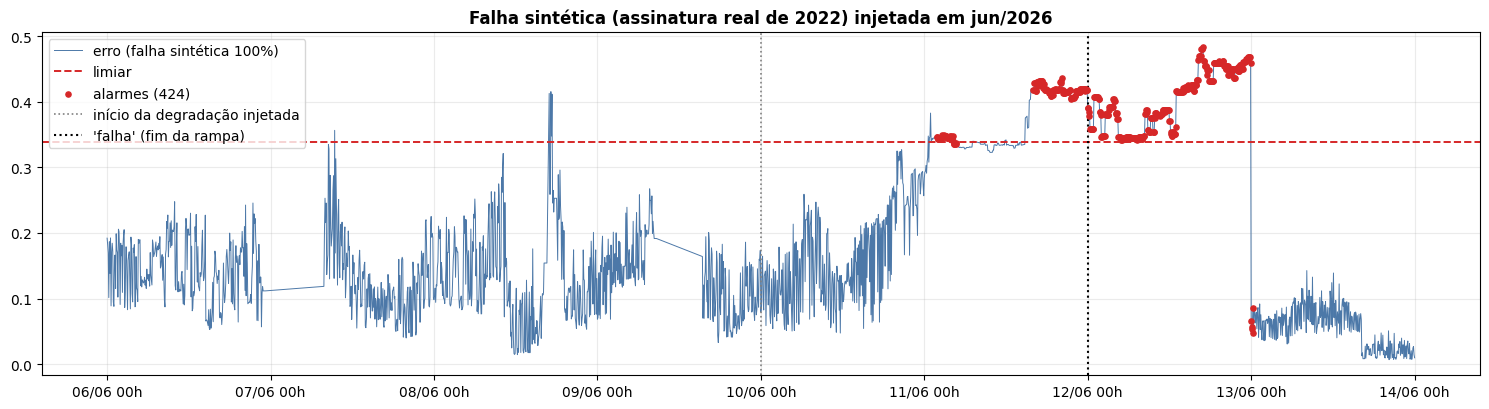

In [5]:
SIG = {"Pressão Sucção": -0.059, "Pressão Descarga": -1.535, "Vibração Bomba LA": 1.515, "Vibração Bomba LNA": 1.237, "Temperatura Bomba LA": 6.699}
T0 = pd.Timestamp("2026-06-10"); RAMP_H, HOLD_H = 48, 24; t_fail = T0 + pd.Timedelta(hours=RAMP_H)
rows, e_plot, f_plot = [], None, None
for scale in (1.0, 0.5, 0.25):
    inj = raw.copy(); dt_h = np.asarray((inj.index - T0).total_seconds())/3600.0
    prof = np.clip(dt_h/RAMP_H, 0, 1); prof = np.where(dt_h < 0, 0, prof); prof = np.where(dt_h > RAMP_H+HOLD_H, 0, prof)
    running = (inj["Pressão Descarga"] > 35).values
    for c, dv in SIG.items(): inj[c] = inj[c].values + dv*scale*prof*running
    e = erro(inj); f = kofn(e > THR) & mascara(fisico(inj), e.index)
    win = (e.index >= T0) & (e.index <= t_fail + pd.Timedelta(hours=HOLD_H)); a = f[win]; fi = a[a].index.min() if a.any() else None
    lead = (t_fail - fi) if fi is not None else None
    rows.append({"severidade": f"{int(100*scale)}% da falha de 2022", "1º alarme": str(fi)[:16] if fi is not None else "—",
                 "antecedência": (f"{int(lead.total_seconds()//3600)} h antes" if lead is not None and lead.total_seconds() >= 3600 else ("no evento (<1 h)" if fi is not None else "não detectada"))})
    if scale == 1.0: e_plot, f_plot = e, f
display(pd.DataFrame(rows).set_index("severidade"))
z = e_plot[(e_plot.index >= T0 - pd.Timedelta(days=4)) & (e_plot.index <= t_fail + pd.Timedelta(days=2))]; az = z[f_plot[z.index]]
fig, ax = plt.subplots(figsize=(15, 4.2))
ax.plot(z.index, z, lw=0.7, color="#4C78A8", label="erro (falha sintética 100%)"); ax.axhline(THR, color="#D62728", ls="--", lw=1.4, label="limiar")
ax.scatter(az.index, az, s=14, color="#D62728", zorder=3, label=f"alarmes ({len(az)})")
ax.axvline(T0, color="grey", ls=":", lw=1.2, label="início da degradação injetada"); ax.axvline(t_fail, color="black", ls=":", lw=1.5, label="'falha' (fim da rampa)")
ax.set_title("Falha sintética (assinatura real de 2022) injetada em jun/2026", fontweight="bold"); ax.legend(loc="upper left"); ax.grid(alpha=0.25)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m %Hh")); plt.tight_layout(); plt.show()

**Leitura honesta:** no ponto conservador (FP ≈ 0), uma falha da **magnitude da de 2022** é detectada **~22 h antes**
do seu desenvolvimento completo; metade da severidade ainda gera alarme no evento; um quarto fica abaixo do piso.
É o trade-off deliberado da escolha "zero falso positivo" — ajustável pelo parâmetro y.

---
## Próximos passos (roadmap)
1. **Empacotar** este pacote no `deploy_v2` (modelo + máscara + limiar μ+6σ + persistência 15/20) e atualizar o slide.
2. **Verificar com a operação** os episódios de 06/12/25 e 10/08/26.
3. **Monitor de drift em produção** (passo futuro): acompanhamento semanal da taxa de alarme e do deslocamento de μ/σ do erro;
   manutenção → recalibrar baseline; drift sustentado sem causa física → retreinar (janela 6–12 meses). *Sem retreino
   automático por relógio.*

*Metodologia: autoencoder VAE (AutoML) treinado só em operação normal · limiar = média + 6·σ do erro de reconstrução ·
persistência 15-de-20 · máscara de 90 min após degrau de pressão (>2,4 bar sucção / >4,8 bar descarga em 15 min).*